###**DIP Practical Assignment: Canny Edge detection and Harris Corner Detection**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

**1. Import libraries and image**

In [1]:
#import libraries needed
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

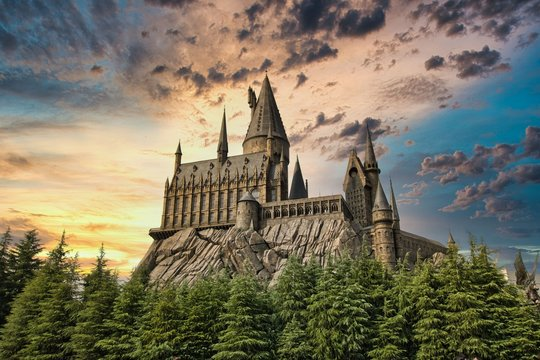

In [2]:
#load and show original image
img=cv2.imread('hogwarts image.jpg')
cv2_imshow(img)

**Pre-req: convert image to grayscale**

Edge and corner detection algorithms operate on single-channel (intensity) images

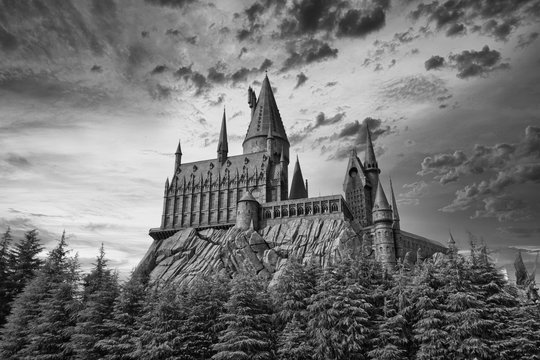

In [3]:
#convert to grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#### **Canny Edge Detection**

The Canny Edge Detection algorithm is a multi-stage process widely considered the optimal standard for edge detection in computer vision. Its primary objective is to identify significant structural boundaries in an image while strictly minimizing the detection of false edges caused by noise.

The algorithm achieves this through a sequence of five distinct mathematical steps:
1. **Noise Reduction (Gaussian Smoothing):** Edge detection relies on intensity derivatives, making it highly sensitive to high-frequency noise. A Gaussian filter is applied to smooth the image, averaging out localized noise spikes.
2. **Gradient Calculation:** The smoothed image is filtered using a derivative operator (typically the Sobel kernel) to compute the first derivatives, $G_x$ and $G_y$. The edge gradient magnitude ($G$) and direction ($\theta$) for every pixel are calculated as:
$$G = \sqrt{G_x^2 + G_y^2}$$
$$\theta = \arctan\left(\frac{G_y}{G_x}\right)$$
3. **Non-Maximum Suppression:** This step "thins" the naturally thick edges resulting from the gradient calculation. The algorithm scans the image and evaluates if each pixel is a local maximum in the direction of the gradient $\theta$. If it is not the highest compared to its neighbors along the gradient angle, its value is suppressed (set to zero).
4. **Double Thresholding:** To filter out spurious edges, two empirical thresholds are applied: a high threshold ($T_{high}$) and a low threshold ($T_{low}$).
    * Strong Edges: Pixels with $G > T_{high}$
    * Weak Edges: Pixels where $T_{low} < G \leq T_{high}$
    * Non-edges: Pixels with $G \leq T_{low}$ are immediately discarded.
5. **Edge Tracking by Hysteresis:** A weak edge pixel is only preserved and promoted to a strong edge if it is physically connected to at least one strong edge pixel. Isolated weak edges are assumed to be noise artifacts and are discarded, resulting in continuous, clean outlines.

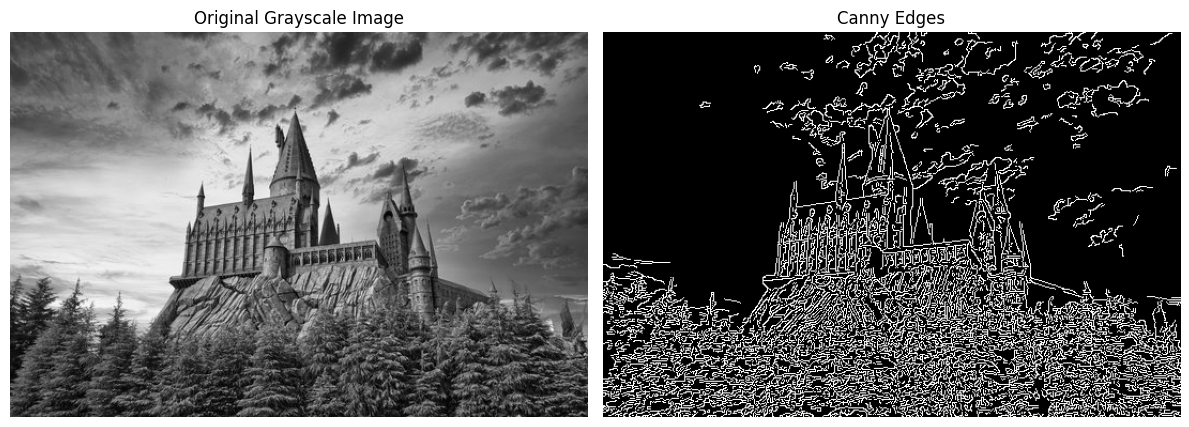

In [4]:
#apply Canny edge detection

#threshold1 (Lower) = 100, threshold2 (Higher) = 200
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

#display the results side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Canny Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

#### **Harris Corner Detection**
While edges represent a change of intensity in one direction, corners represent significant changes of intensity in all directions. Corners are highly useful features in image processing because they are invariant to translation, rotation and illumination.

How it Works:

The Harris Corner Detector mathematically determines if a window of pixels, when shifted in any direction, produces a large variation in intensity. It calculates a score $R$ for each pixel based on the eigenvalues of the gradient structure tensor $M$:$$R = \det(M) - k(\operatorname{trace}(M))^2$$
* If $R$ is small, the region is flat
* If $R$ is negative, the region is an edge
* If $R$ is large and positive, the region is a corner.

In OpenCV, we use `cv2.cornerHarris()` to compute these scores. We then dilate the resulting corner points purely for better visualization and overlay them on the original image.

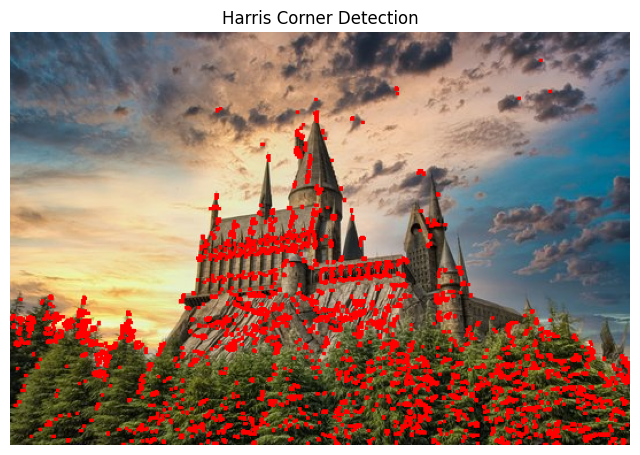

In [5]:
#Harris corner detection requires the grayscale image to be of float32 type
gray_float = np.float32(gray)

#apply Harris corner detector

#parameters:
'''
image - Input image (grayscale, float32)
blockSize - Size of neighborhood considered for corner detection
ksize - Aperture parameter of Sobel derivative used
k - Harris detector free parameter in the equation (usually 0.04 to 0.06)
'''
dst = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

#dilate the result to mark the corners more clearly (makes the points thicker)
dst = cv2.dilate(dst, None)

#create a copy of the original color image to draw the corners on
img_with_corners = img.copy()

#threshold for an optimal value, it may vary depending on the image.
#we mark pixels as red [0, 0, 255] in BGR format where the corner response is > 1% of the maximum
img_with_corners[dst > 0.01 * dst.max()] = [0, 0, 255]

#convert BGR to RGB for correct color plotting in Matplotlib
img_with_corners_rgb = cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB)

#display the results
plt.figure(figsize=(8, 6))
plt.imshow(img_with_corners_rgb)
plt.title("Harris Corner Detection")
plt.axis('off')
plt.show()